### Step 1: Mount the Google Drive

Remember to use GPU runtime before mounting your Google Drive. (Runtime --> Change runtime type).

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Step 2: Open the project directory

Replace `Your_Dir` with your own path.

In [2]:
cd /content/drive/MyDrive/emg2qwerty

/content/drive/MyDrive/emg2qwerty


### Step 3: Install required packages

After installing them, Colab will require you to restart the session.

In [3]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.6/553.6 kB 7.7 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 5.8 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
INFO: pip is looking at multiple versions of typer to determine which 

### Step 4: Start your experiments!

- Remember to download and copy the dataset to this directory: `Your_Dir/emg2qwerty/data`.
- You may now start your experiments with any scripts! Below are examples of single-user training and testing (greedy decoding).
- **There are two ways to track the logs:**
  - 1. Keep `--multirun`, and the logs will not be printed here, but they will be saved in the folder `logs`, e.g., `logs/2025-02-09/18-24-15/submitit_logs/`.
  - 2. Comment out `--multirun` and the logs will be printed in this notebook, but they will not be saved.

#### Training

- The checkpoints are saved in the folder `logs`, e.g., `logs/2025-02-09/18-24-15/checkpoints/`.

In [3]:
# Single-user training
!python -m emg2qwerty.train \
  user="single_user" \
  trainer.accelerator=gpu trainer.devices=1 \
  trainer.max_epochs=40
  # --multirun

[2026-03-04 08:32:24,797][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f

#### Testing:

- Replace `Your_Path_to_Checkpoint` with your checkpoint path.

In [7]:
# Single-user testing
!python -m emg2qwerty.train \
  user="single_user" \
  checkpoint="/content/drive/MyDrive/emg2qwerty/logs/2026-03-04/08-32-24/checkpoints/epoch\=39-step\=4800.ckpt" \
  train=False trainer.accelerator=gpu \
  decoder=ctc_greedy \
  hydra.launcher.mem_gb=64 \
  # --multirun

[2026-03-04 09:06:47,755][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f

Baseline metrics:
val_CER: 22.552061080932617
val_IER: 5.981391429901123
val_DER: 2.0602569580078125
val_SER: 14.510412216186523
val_loss: 0.7416194677352905
test_CER: 24.18413734436035
test_IER: 6.267560005187988
test_DER: 2.139615297317505
test_SER: 15.776961326599121
test_loss: 0.7690999507904053


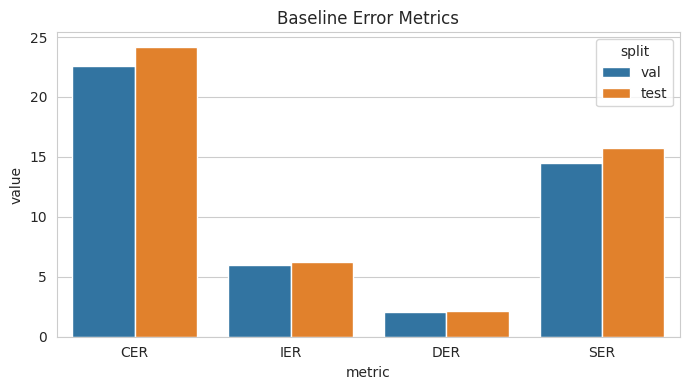

In [13]:
import os
import re
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorboard.backend.event_processing import event_accumulator

RUN_DIR = "/content/drive/MyDrive/emg2qwerty/logs/2026-03-04/09-06-47"

def get_last_from_events(run_dir, tag_candidates):
    event_files = sorted(
        glob.glob(os.path.join(run_dir, "lightning_logs", "version_*", "events.out.tfevents*")),
        key=os.path.getmtime
    )
    latest_val = None
    for ev in event_files:
        try:
            ea = event_accumulator.EventAccumulator(ev)
            ea.Reload()
            tags = set(ea.Tags().get("scalars", []))
            for t in tag_candidates:
                if t in tags:
                    vals = ea.Scalars(t)
                    if vals:
                        latest_val = vals[-1].value  # keep latest found across files
        except Exception:
            pass
    return latest_val

def get_from_log(run_dir, key):
    log_path = os.path.join(run_dir, "emg2qwerty.log")
    if not os.path.exists(log_path):
        return None
    with open(log_path, "r", encoding="utf-8", errors="ignore") as f:
        txt = f.read()

    # dict-style print at end: 'val/CER': 22.55
    m = re.findall(rf"'{re.escape(key)}'\s*:\s*([0-9]+(?:\.[0-9]+)?)", txt)
    if m:
        return float(m[-1])

    # table style
    m = re.findall(rf"{re.escape(key)}\s*[\|\u2502]\s*([0-9]+(?:\.[0-9]+)?)", txt)
    if m:
        return float(m[-1])

    return None

def metric(run_dir, key, tag_candidates):
    v = get_last_from_events(run_dir, tag_candidates)
    if v is None:
        v = get_from_log(run_dir, key)
    return v

metrics = {
    "val_CER":  metric(RUN_DIR, "val/CER",  ["val/CER", "val/CER_epoch", "val_cer"]),
    "val_IER":  metric(RUN_DIR, "val/IER",  ["val/IER", "val/IER_epoch"]),
    "val_DER":  metric(RUN_DIR, "val/DER",  ["val/DER", "val/DER_epoch"]),
    "val_SER":  metric(RUN_DIR, "val/SER",  ["val/SER", "val/SER_epoch"]),
    "val_loss": metric(RUN_DIR, "val/loss", ["val/loss", "val/loss_epoch", "val_loss"]),
    "test_CER":  metric(RUN_DIR, "test/CER",  ["test/CER", "test/CER_epoch", "test_cer"]),
    "test_IER":  metric(RUN_DIR, "test/IER",  ["test/IER", "test/IER_epoch"]),
    "test_DER":  metric(RUN_DIR, "test/DER",  ["test/DER", "test/DER_epoch"]),
    "test_SER":  metric(RUN_DIR, "test/SER",  ["test/SER", "test/SER_epoch"]),
    "test_loss": metric(RUN_DIR, "test/loss", ["test/loss", "test/loss_epoch", "test_loss"]),
}

print("Baseline metrics:")
for k, v in metrics.items():
    print(f"{k}: {v}")

# Save
pd.DataFrame([metrics]).to_csv(os.path.join(RUN_DIR, "baseline_metrics.csv"), index=False)

# Plot
sns.set_style("whitegrid")
err_df = pd.DataFrame({
    "metric": ["CER", "IER", "DER", "SER"],
    "val": [metrics["val_CER"], metrics["val_IER"], metrics["val_DER"], metrics["val_SER"]],
    "test": [metrics["test_CER"], metrics["test_IER"], metrics["test_DER"], metrics["test_SER"]],
}).melt(id_vars="metric", var_name="split", value_name="value").dropna()

plt.figure(figsize=(7,4))
sns.barplot(data=err_df, x="metric", y="value", hue="split")
plt.title("Baseline Error Metrics")
plt.tight_layout()
plt.show()